In [1]:
# =====================================
# Imports
# =====================================

import pandas as pd
import numpy as np


# =====================================
# Load Raw Data
# =====================================

df = pd.read_csv("steam_games.csv")


# =====================================
# Remove duplicates
# =====================================

df = df.drop_duplicates(subset="game_name")


# =====================================
# Clean Price
# =====================================

df["price"] = df["price"].str.replace("₹","", regex=False)
df["price"] = df["price"].str.replace(",","", regex=False)
df["price"] = df["price"].str.replace("Free","0", regex=False)

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["price"] = df["price"].fillna(0)


# =====================================
# Clean Release Date
# =====================================

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

df = df.dropna(subset=["release_year"])

df["release_year"] = df["release_year"].astype(int)
df["release_month"] = df["release_month"].astype(int)

df = df.drop(columns=["release_date"])


# =====================================
# Extract Review Score
# =====================================

df["review_score"] = df["rating_label"].str.extract(r"(\d+)%")

df["review_score"] = pd.to_numeric(df["review_score"], errors="coerce")

df = df.dropna(subset=["review_score"])

df["review_score"] = df["review_score"].astype(int)


# =====================================
# Extract Review Sentiment Text
# =====================================

df["review_sentiment"] = df["rating_label"].str.extract(r"^(.*?)(?=\d)")


# =====================================
# Drop Unused Column
# =====================================

df = df.drop(columns=["rating_label"])


# =====================================
# Clean Genres
# =====================================

df["genres"] = df["genres"].str.split(",").str[:3]

df["genres"] = df["genres"].apply(
    lambda x: ",".join(x) if isinstance(x, list) else x
)


valid_genres = [
"Action","Adventure","RPG","Strategy","Simulation","Sports",
"Racing","Casual","Indie","Free To Play","Massively Multiplayer",
"Early Access","Puzzle","Horror","Platformer","Shooter"
]


def clean_genres(genres):

    if pd.isna(genres):
        return None

    items = [g.strip() for g in genres.split(",")]

    filtered = [g for g in items if g in valid_genres]

    return ",".join(filtered)


df["genres"] = df["genres"].apply(clean_genres)

df = df.dropna(subset=["genres"])


# =====================================
# Create Target Variable
# =====================================

df["review_score_category"] = pd.cut(
    df["review_score"],
    bins=[0,60,75,85,100],
    labels=["Bad","Average","Good","Excellent"]
)


# =====================================
# Save Clean Dataset
# =====================================

df.to_csv("steam_games_cleaned.csv", index=False)

print("Clean dataset saved.")

Clean dataset saved.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1964 non-null   int64  
 1   game_name              1964 non-null   object 
 2   price                  1964 non-null   float64
 3   review_count           1964 non-null   float64
 4   developer              1964 non-null   object 
 5   publisher              1935 non-null   object 
 6   genres                 1951 non-null   object 
 7   release_year           1964 non-null   int64  
 8   release_month          1964 non-null   int64  
 9   review_score           1964 non-null   int64  
 10  review_sentiment       1964 non-null   object 
 11  review_score_category  1964 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 184.3+ KB
None
        Unnamed: 0         price  review_count  release_year  release_month  \
count  1964.00000

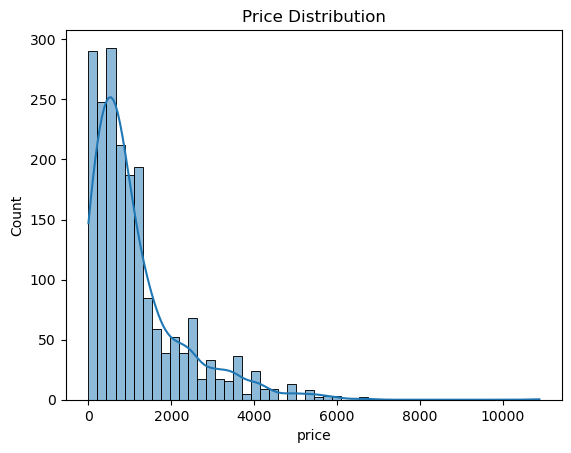

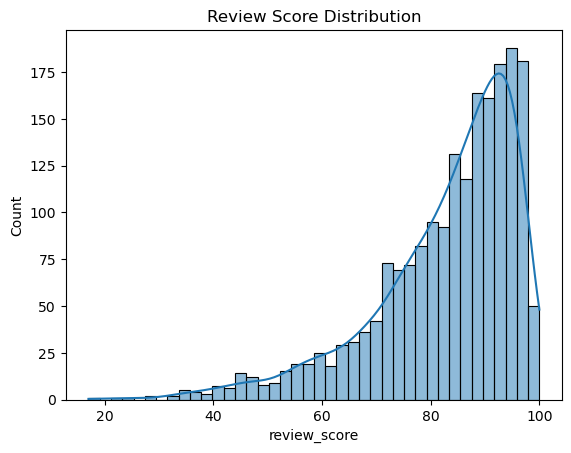

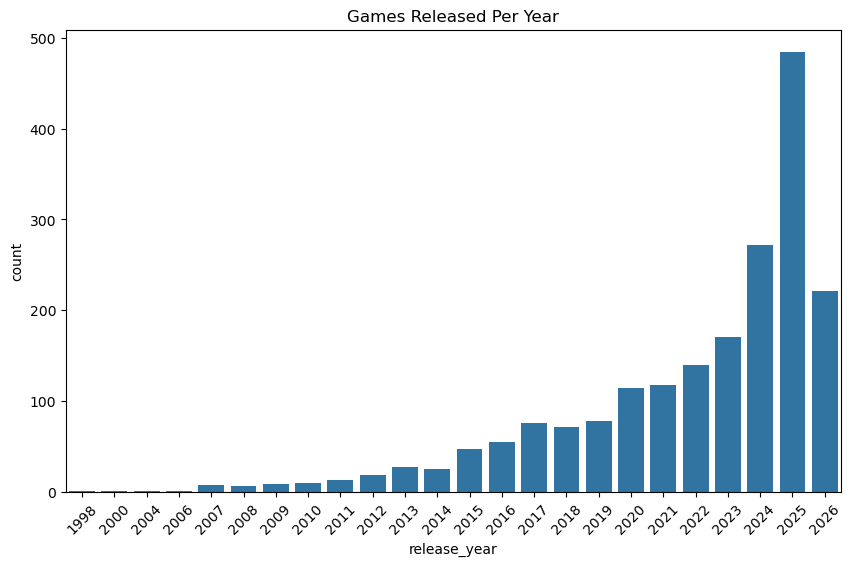

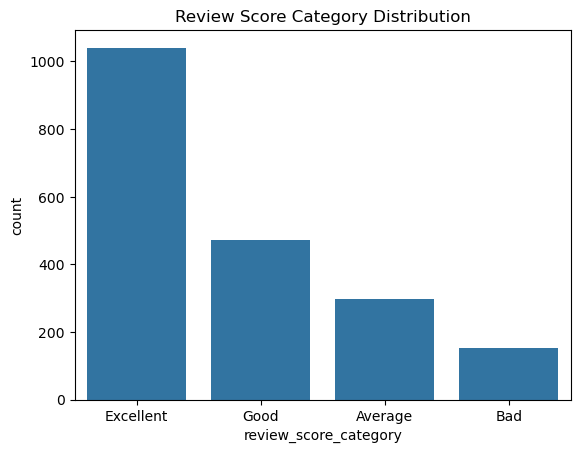

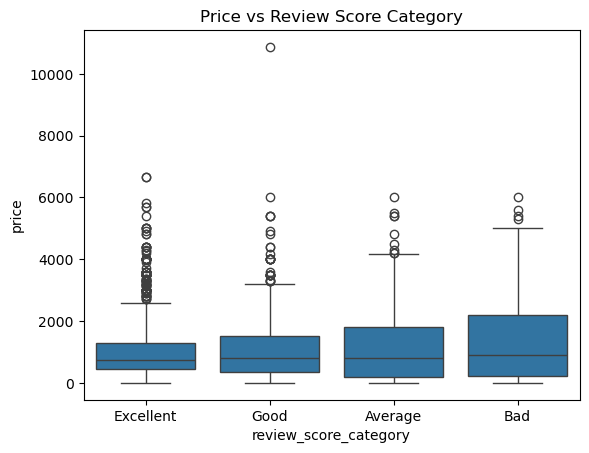

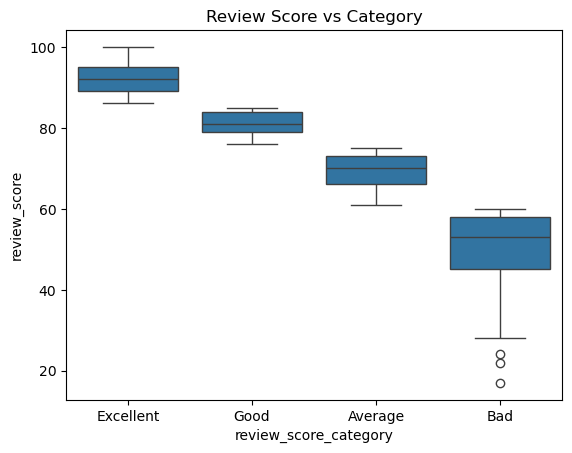

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("steam_games_cleaned.csv")


# =====================================
# Basic info
# =====================================

print(df.info())
print(df.describe())


# =====================================
# Price Distribution
# =====================================

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Price Distribution")

plt.show()


# =====================================
# Review Score Distribution
# =====================================

sns.histplot(df["review_score"], bins=40, kde=True)

plt.title("Review Score Distribution")

plt.show()


# =====================================
# Release Year Distribution
# =====================================

plt.figure(figsize=(10,6))

sns.countplot(
    x="release_year",
    data=df,
    order=sorted(df["release_year"].unique())
)

plt.xticks(rotation=45)

plt.title("Games Released Per Year")

plt.show()


# =====================================
# Target Distribution
# =====================================

sns.countplot(x="review_score_category", data=df)

plt.title("Review Score Category Distribution")

plt.show()


# =====================================
# Price vs Review Score Category
# =====================================

sns.boxplot(
    x="review_score_category",
    y="price",
    data=df
)

plt.title("Price vs Review Score Category")

plt.show()


# =====================================
# Review Score vs Category
# =====================================

sns.boxplot(
    x="review_score_category",
    y="review_score",
    data=df
)

plt.title("Review Score vs Category")

plt.show()

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


# Load data
df = pd.read_csv("steam_games_cleaned.csv")


# Drop ALL review-related columns
df = df.drop(columns=[
    "review_score",
    "review_sentiment",
    "review_count",
    "log_review_count",
    "rating_label"
], errors="ignore")


# Drop identifiers
df = df.drop(columns=[
    "game_name",
    "developer",
    "publisher"
], errors="ignore")


# Genre encoding
genre_dummies = df["genres"].str.get_dummies(",")

df = pd.concat([df.drop(columns=["genres"]), genre_dummies], axis=1)


# Feature engineering
df["game_age"] = 2026 - df["release_year"]
df = df.drop(columns=["release_year"])


df["log_price"] = np.log1p(df["price"])

df["price_bucket"] = pd.cut(
    df["price"],
    bins=[-1,0,500,1500,3000,df["price"].max()+1],
    labels=["Free","Cheap","Mid","Expensive","Premium"]
)

df = df.drop(columns=["price"])


# Encode target
target_map = {
    "Bad":0,
    "Average":1,
    "Good":2,
    "Excellent":3
}

df["review_score_category"] = df["review_score_category"].map(target_map)


# Split
X = df.drop(columns=["review_score_category"])
y = df["review_score_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Feature groups
cat_cols = ["price_bucket"]
num_cols = [c for c in X.columns if c not in cat_cols]


# Preprocessing
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])


# Models
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        eval_metric="mlogloss"
    )
}


# Train & evaluate
for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"\n{name} Accuracy: {acc:.3f}")
    print(classification_report(y_test, preds))


RandomForest Accuracy: 0.542
              precision    recall  f1-score   support

           0       0.43      0.19      0.27        31
           1       0.30      0.20      0.24        60
           2       0.34      0.18      0.24        94
           3       0.62      0.86      0.72       208

    accuracy                           0.54       393
   macro avg       0.42      0.36      0.36       393
weighted avg       0.49      0.54      0.49       393


GradientBoosting Accuracy: 0.511
              precision    recall  f1-score   support

           0       0.25      0.13      0.17        31
           1       0.24      0.15      0.19        60
           2       0.31      0.19      0.24        94
           3       0.60      0.82      0.70       208

    accuracy                           0.51       393
   macro avg       0.35      0.32      0.32       393
weighted avg       0.45      0.51      0.47       393


XGBoost Accuracy: 0.509
              precision    recall  f1-sco